# Tarea 1: Productividad Estudiantil
### Pablo Ignacio Cortés Vielma
### 2021458476
### Ingenieria civil industrial

## Pregunta 1: Carga, exploración y limpieza de datos



In [72]:
import math
import matplotlib.pyplot as plt
import missingno as msn
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Configuración de estilo visual
sns.set_theme(style='whitegrid')


In [73]:
# Carga de la BD
df = pd.read_csv('../../data/student_productivity.csv')
display(df.info())
print('\nTotal datos iniciales:', len(df))
display(df.describe())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5621 entries, 0 to 5620
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            5621 non-null   int64  
 1   age                   4973 non-null   float64
 2   gender                5063 non-null   object 
 3   academic_level        4991 non-null   object 
 4   study_hours           5047 non-null   float64
 5   self_study_hours      4954 non-null   float64
 6   online_classes_hours  4939 non-null   float64
 7   social_media_hours    4965 non-null   float64
 8   gaming_hours          4965 non-null   float64
 9   sleep_hours           5068 non-null   float64
 10  screen_time_hours     5035 non-null   float64
 11  exercise_minutes      5022 non-null   object 
 12  caffeine_intake_mg    5021 non-null   float64
 13  part_time_job         4918 non-null   object 
 14  upcoming_deadline     4904 non-null   float64
 15  internet_quality     

None


Total datos iniciales: 5621


,student_id,age,study_hours,self_study_hours,online_classes_hours,social_media_hours,gaming_hours,sleep_hours,screen_time_hours,caffeine_intake_mg,upcoming_deadline,mental_health_score,drug_use,focus_index,burnout_level,productivity_score,exam_score
count,5621.000000,4973.000000,5047.000000,4954.000000,4939.000000,4965.000000,4965.000000,5068.000000,5035.000000,5021.000000,4904.000000,4946.000000,1518.000000,4988.000000,4905.000000,4983.000000,4912.000000
mean,2811.000000,20.510557,4.538708,2.480454,2.012296,3.002872,1.571458,7.023301,6.979045,250.804820,0.501223,5.516983,0.661397,29.388119,45.633156,37.313526,18.840542
std,1622.787263,2.876399,1.819412,1.178094,0.983104,1.472740,1.112557,1.159948,2.482912,143.685652,0.500049,2.873859,0.473391,9.996024,14.257283,16.841997,12.119456
min,1.000000,16.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,1406.000000,18.000000,3.260000,1.660000,1.320000,2.000000,0.680000,6.250000,5.280000,129.000000,0.000000,3.000000,0.000000,22.460000,35.770000,25.330000,9.410000
50%,2811.000000,20.000000,4.530000,2.480000,2.010000,2.990000,1.500000,7.015000,6.950000,251.000000,1.000000,5.000000,1.000000,29.380000,45.650000,36.920000,17.990000
75%,4216.000000,23.000000,5.760000,3.280000,2.690000,4.030000,2.350000,7.820000,8.705000,375.000000,1.000000,8.000000,1.000000,36.232500,55.410000,49.200000,27.410000
max,5621.000000,25.000000,11.840000,7.410000,6.000000,8.280000,5.640000,10.000000,15.300000,499.000000,1.000000,10.000000,1.000000,63.480000,97.580000,98.020000,64.090000


In [74]:
# Creación de la variable que indica si rindieron el test
df['rindio_exam'] = (df['exam_score'] != 1.0).astype(int)


### Limpieza Inicial de Duplicados Categóricos

Se detectaron errores en las categorias de las variables "academic_level" y "part_time_job", por lo tanto se procede a estandarizar las categorias para no tener categorias duplicadas.

In [75]:
print("Valores únicos iniciales en 'academic_level':", df['academic_level'].unique())
print("Valores únicos iniciales en 'part_time_job':", df['part_time_job'].unique())

# Estandarización de Part Time Job
df['part_time_job'] = df['part_time_job'].astype(str).str.strip().str.capitalize()
df['part_time_job'] = df['part_time_job'].replace('Nan', np.nan)

# Estandarización de Academic Level
df['academic_level'] = df['academic_level'].astype(str).str.strip().str.capitalize()
df['academic_level'] = df['academic_level'].replace('Nan', np.nan)

print("\nValores corregidos en 'academic_level':", df['academic_level'].dropna().unique())
print("Valores corregidos en 'part_time_job':", df['part_time_job'].dropna().unique())

Valores únicos iniciales en 'academic_level': ['Undergraduate' 'High School' 'Undergraduate ' 'Postgraduate' nan
 'High School ' 'Postgraduate ']
Valores únicos iniciales en 'part_time_job': ['No' 'no' 'Yes' 'yes' nan]

Valores corregidos en 'academic_level': ['Undergraduate' 'High school' 'Postgraduate']
Valores corregidos en 'part_time_job': ['No' 'Yes']


### Exploración Visual de Datos Faltantes (Nulos)

student_id                 0
age                      648
gender                   558
academic_level           630
study_hours              574
self_study_hours         667
online_classes_hours     682
social_media_hours       656
gaming_hours             656
sleep_hours              553
screen_time_hours        586
exercise_minutes         599
caffeine_intake_mg       600
part_time_job            703
upcoming_deadline        717
internet_quality         523
mental_health_score      675
drug_use                4103
focus_index              633
burnout_level            716
productivity_score       638
exam_score               709
rindio_exam                0
dtype: int64


<Figure size 1000x600 with 0 Axes>

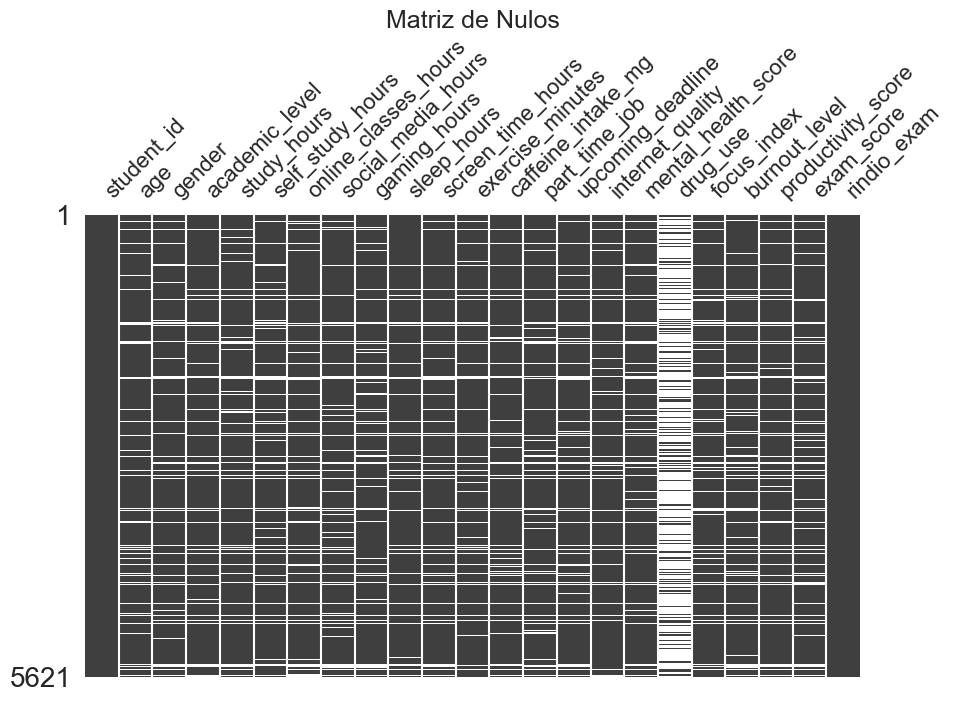

In [76]:
# Cantidad exacta de nulos por variable
print(df.isnull().sum())

# Visualización de matriz de datos faltantes
plt.figure(figsize=(10, 6))
msn.matrix(df, figsize=(10, 6), sparkline=False)
plt.title('Matriz de Nulos', fontsize=18)
plt.show()

### Distribución de Variables Continuas (Boxplots Dinámicos)

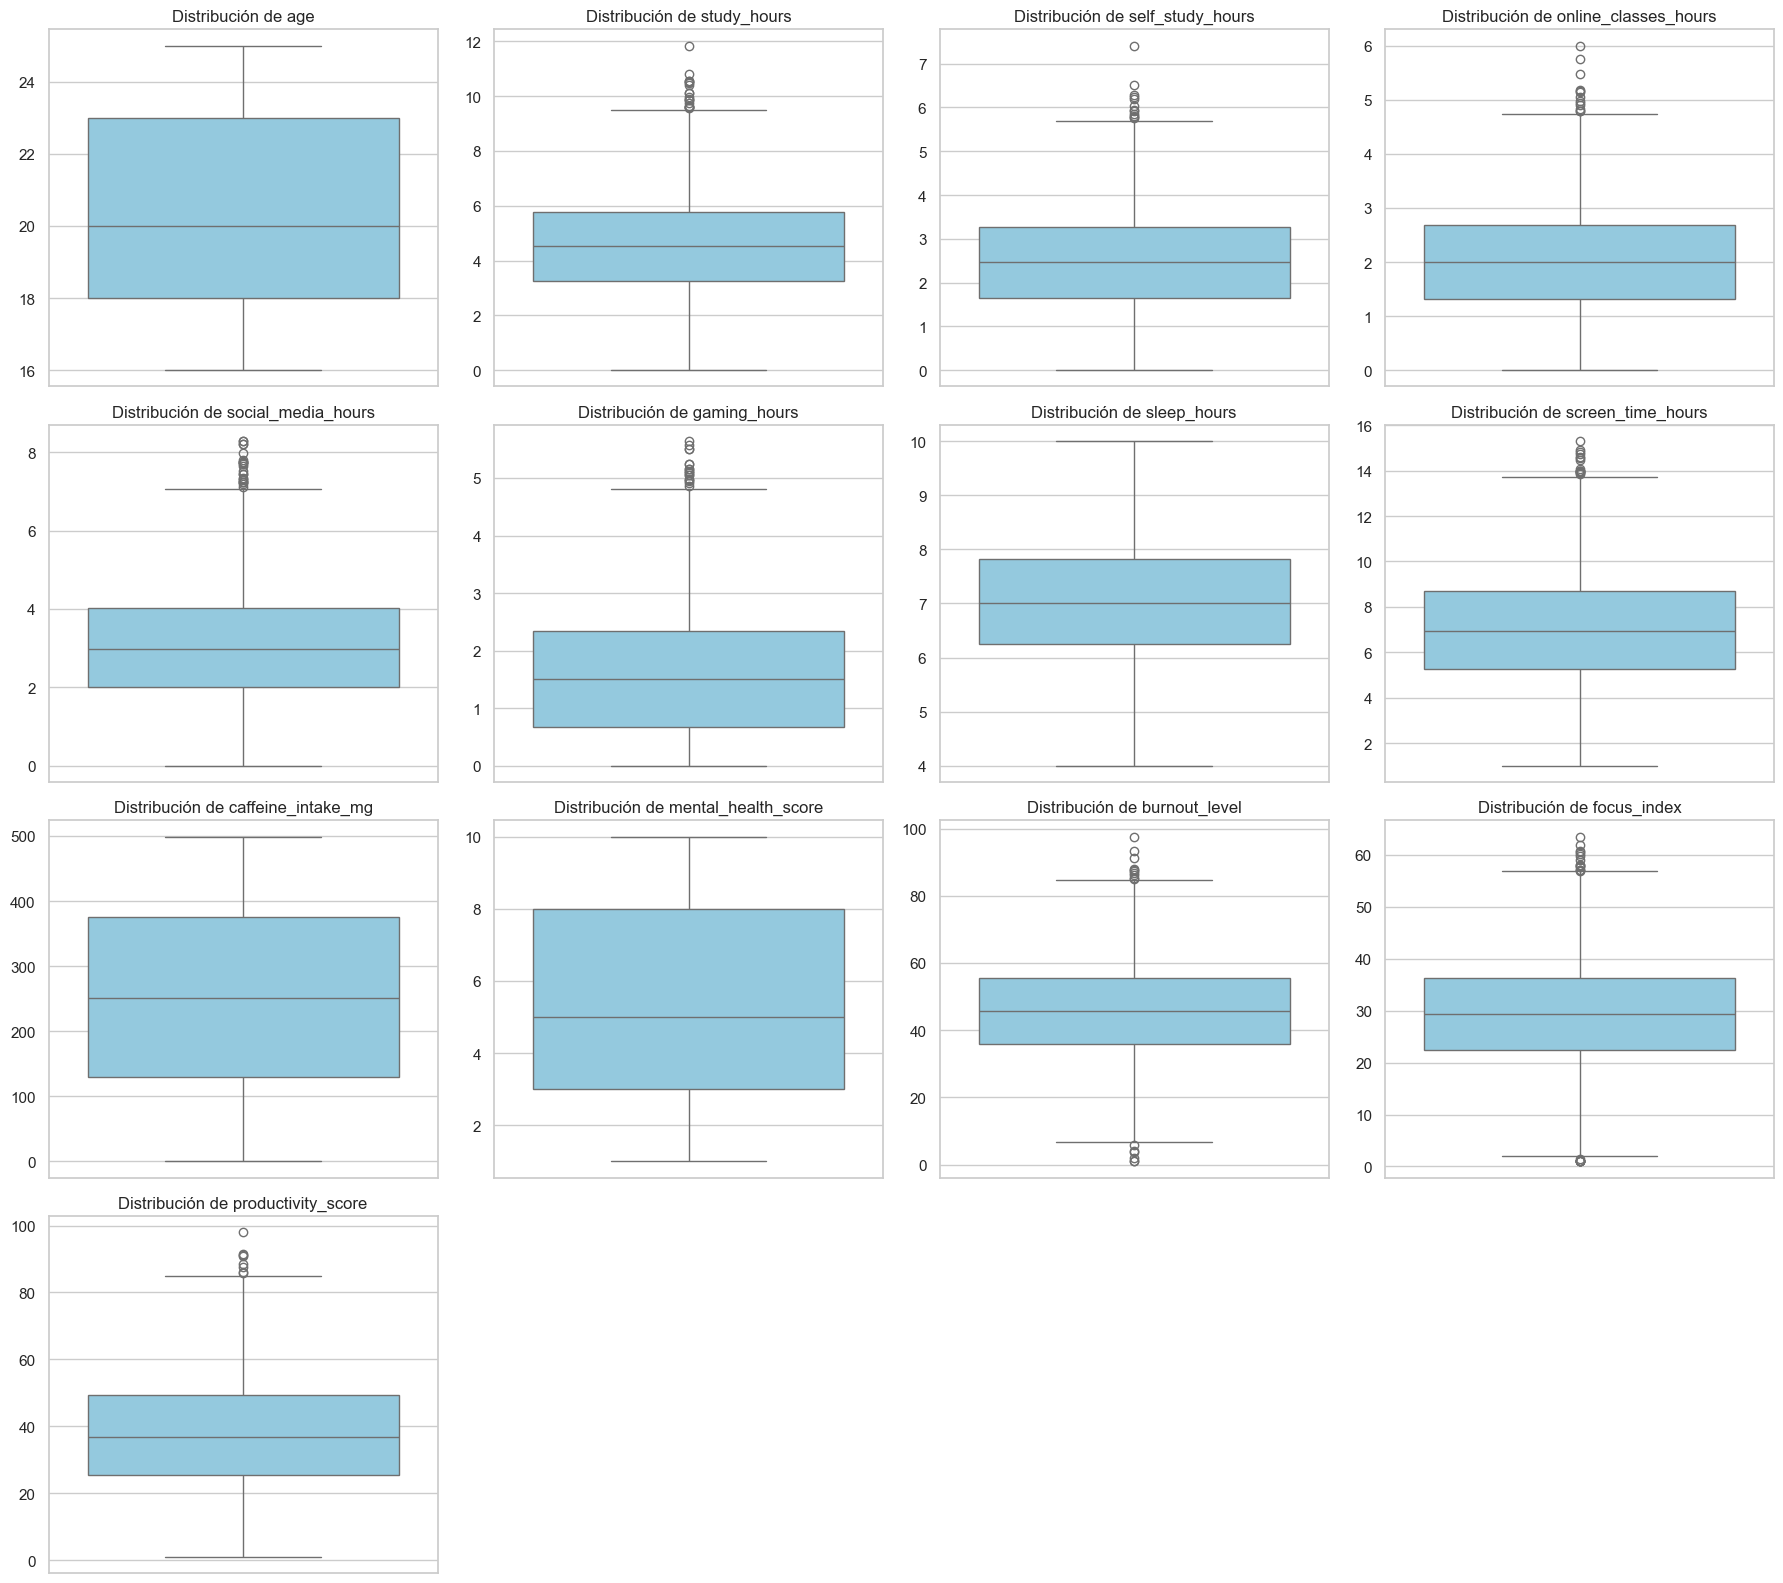

In [77]:
# Boxplots Dinámicos
variables_interes = [
    'age', 'study_hours', 'self_study_hours', 'online_classes_hours', 
    'social_media_hours', 'gaming_hours', 'sleep_hours', 'screen_time_hours', 
    'caffeine_intake_mg', 'mental_health_score', 'burnout_level', 'focus_index', 
    'productivity_score'
]

n_cols = 4
n_rows = math.ceil(len(variables_interes) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten() 

for i, col in enumerate(variables_interes):
    if col in df.columns:
        sns.boxplot(y=df[col], ax=axes[i], color='skyblue')
        axes[i].set_title(f'Distribución de {col}', fontsize=12)
        axes[i].set_ylabel('')

# Apagar los ejes sobrantes
for j in range(len(variables_interes), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

### Comportamiento de Variables Categóricas

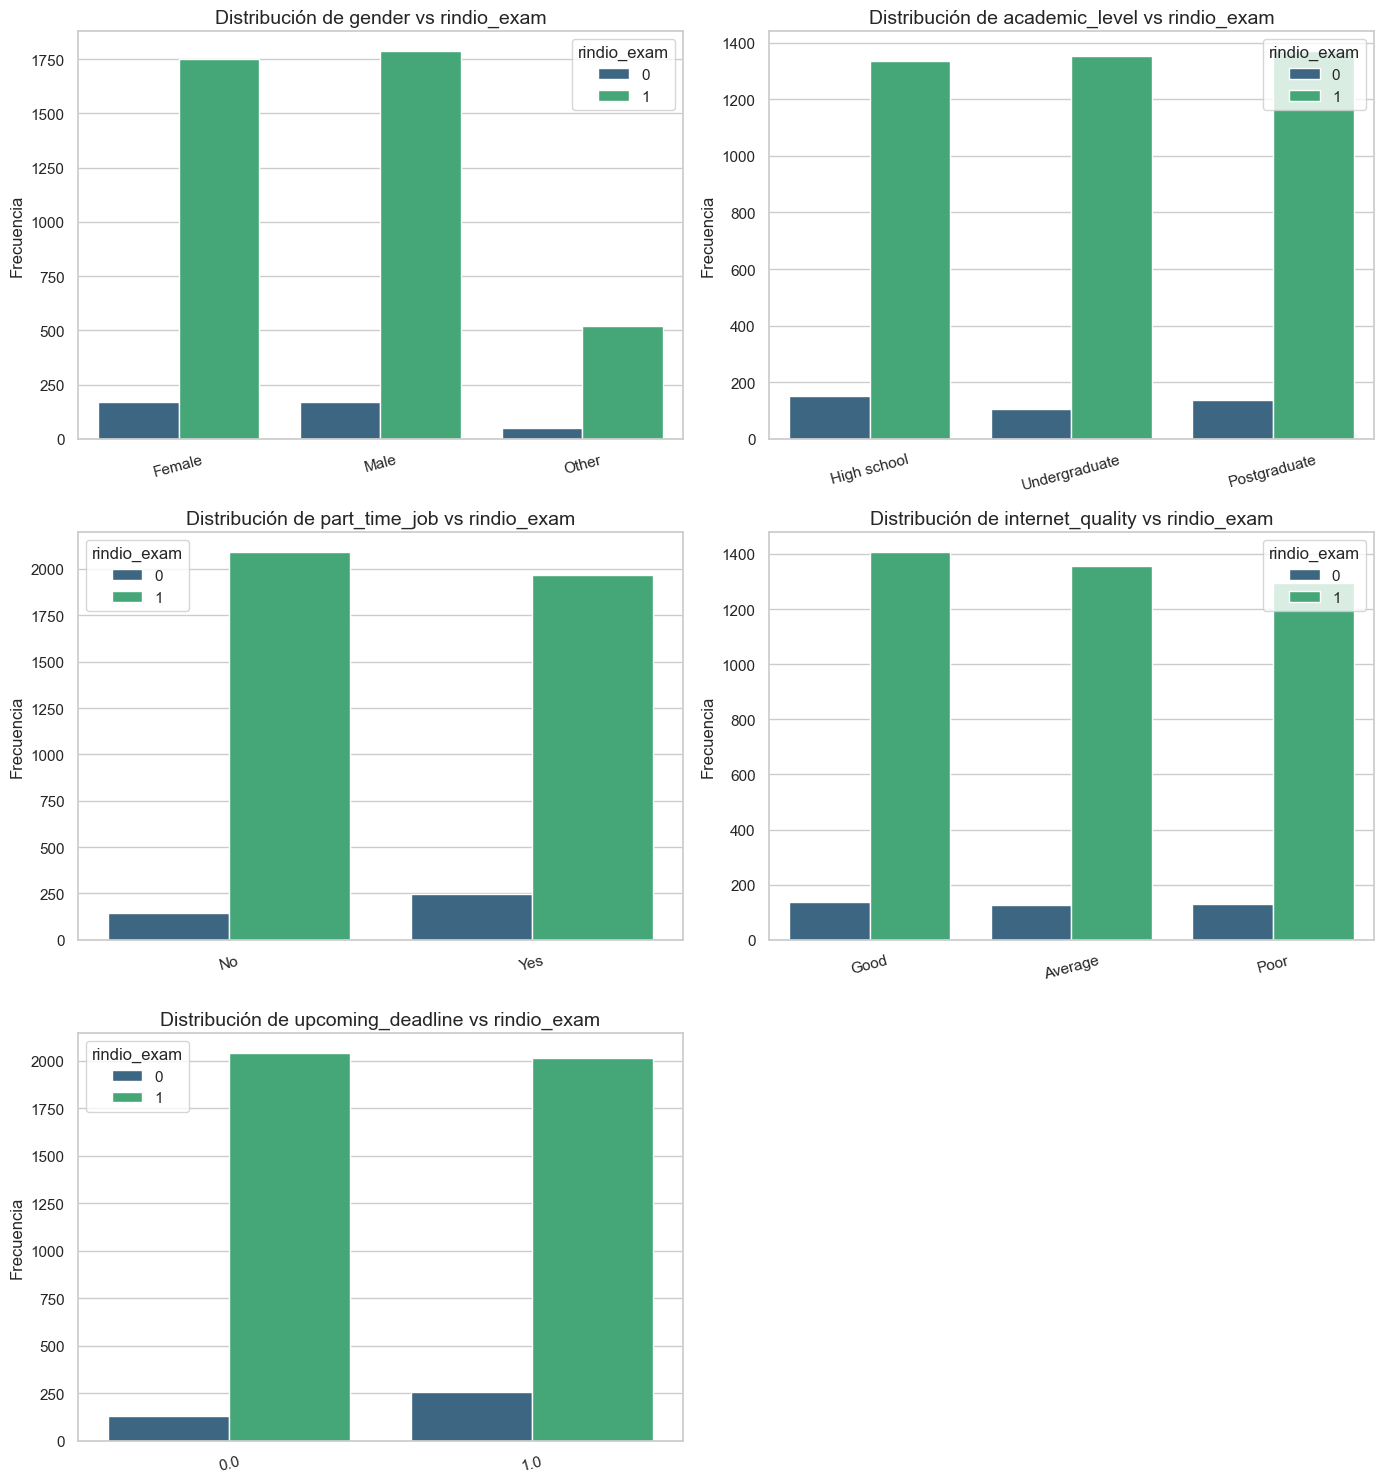

In [ ]:
variables_categoricas = [
    'gender', 'academic_level', 'part_time_job', 
    'internet_quality', 'upcoming_deadline'
]

n_cols_cat = 2
n_rows_cat = math.ceil(len(variables_categoricas) / n_cols_cat)

fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(14, 5 * n_rows_cat))
axes = axes.flatten()

for i, col in enumerate(variables_categoricas):
    if col in df.columns:
        # Frecuencias divididas por "rindio_exam"
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue='rindio_exam')
        axes[i].set_title(f'Distribución de {col} vs rindio_exam', fontsize=14)
        axes[i].set_ylabel('Frecuencia')
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=15)

for j in range(len(variables_categoricas), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

### Correlaciones (Mapas de Calor)

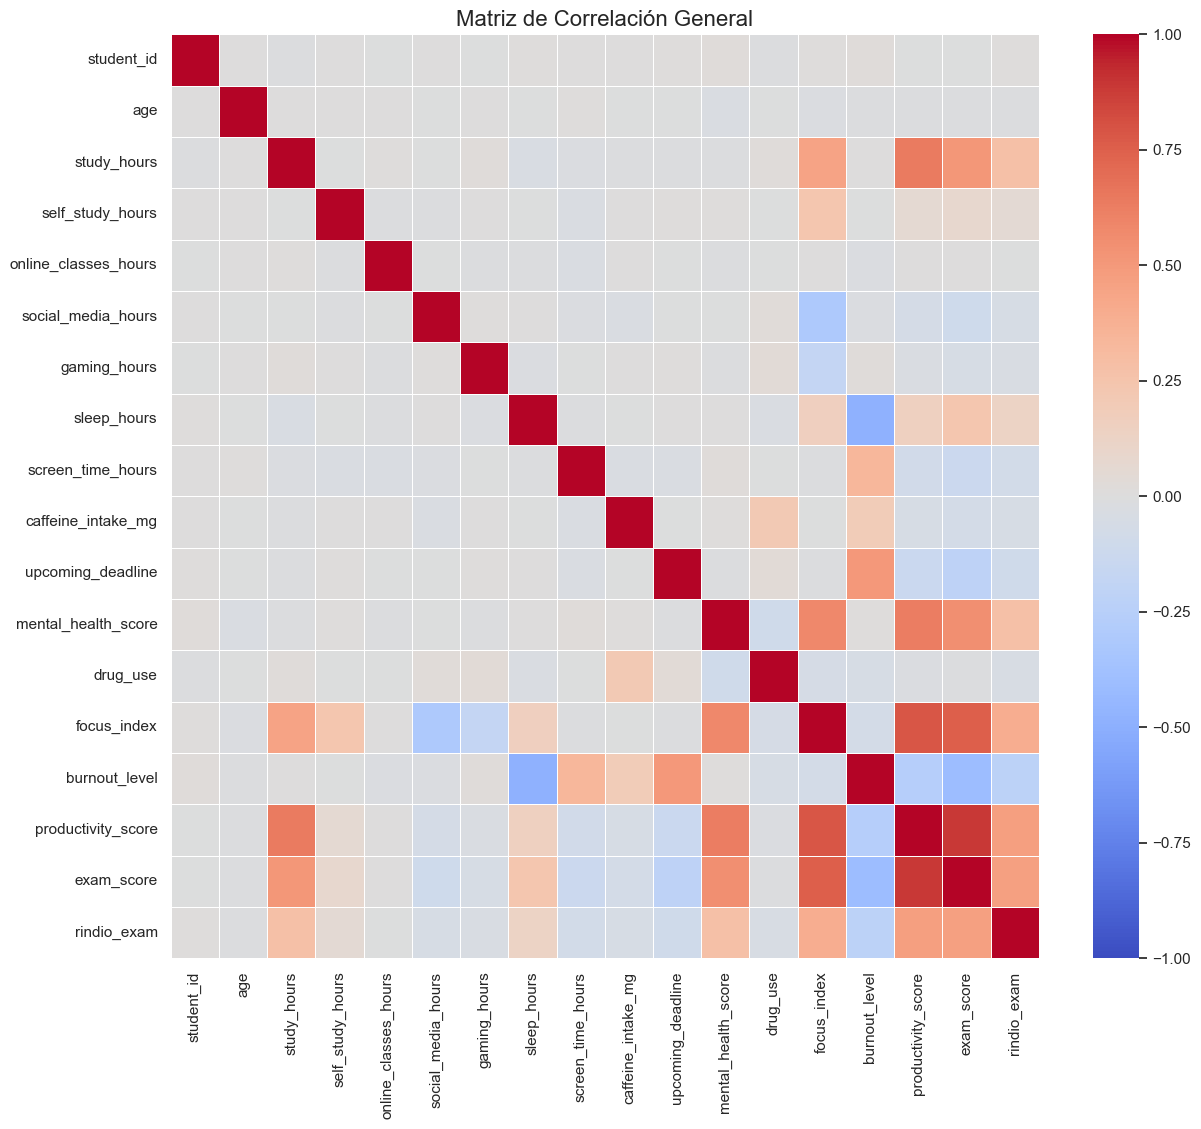

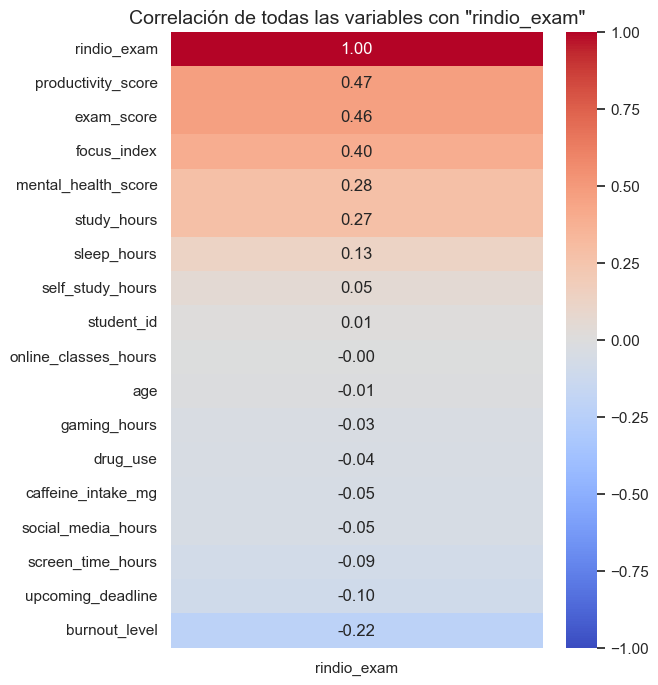

In [79]:
# Seleccionamos solo variables numéricas para el heatmap
columnas_numericas = df.select_dtypes(include=['float64', 'int64'])
matriz_correlacion = columnas_numericas.corr()

# Heatmap General
plt.figure(figsize=(14, 12))
sns.heatmap(matriz_correlacion, annot=False, cmap='coolwarm', linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación General', fontsize=16)
plt.show()

# Heatmap Enfocado solo en nuestra variable dependiente: rindio_exam
plt.figure(figsize=(6, 8))
correlacion_test = matriz_correlacion[['rindio_exam']].sort_values(by='rindio_exam', ascending=False)
sns.heatmap(correlacion_test, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlación de todas las variables con "rindio_exam"', fontsize=14)
plt.show()



### Tratamiento de valores nulos
Para la limpieza de los valores nulos en la data se procedio a realizar los siguientes procesos.
1. Se elimina la variable "drug_use", la cual presenta alta cantidad de nulos, siendo imposible imputar sin generar un alto sesgo.

2. Se imputan variables continuas usando su mediana, esto debido a nuestra exploración de gráficas boxplot, cuyas distribuciones muestran que un valor promedio sería engañoso por el tema de outliers.

3. No se debe imputar variables a predecir ("exam_score", nuestra variable de la cual nace "rindio_exam"). Por tal motivo, las filas que no cuenten con este dato les aplicaremos ".dropna()".

In [80]:
# Borrado de Drop_Use
if 'drug_use' in df.columns:
    df = df.drop(columns=['drug_use'])

# Imputación via Medianas
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns
columnas_numericas = columnas_numericas.drop(['exam_score', 'rindio_exam', 'student_id'], errors='ignore')

for col in columnas_numericas:
    df[col] = df[col].fillna(df[col].median())

# Filtro Fila sobre categóricos / target missing restantes
df = df.dropna().copy()

print("\nFilas finales y completamente funcionales:", len(df))
print("Valores perdidos restantes:\n", df.isnull().sum().sum())



Filas finales y completamente funcionales: 4450
Valores perdidos restantes:
 0


student_id              0
age                     0
gender                  0
academic_level          0
study_hours             0
self_study_hours        0
online_classes_hours    0
social_media_hours      0
gaming_hours            0
sleep_hours             0
screen_time_hours       0
exercise_minutes        0
caffeine_intake_mg      0
part_time_job           0
upcoming_deadline       0
internet_quality        0
mental_health_score     0
focus_index             0
burnout_level           0
productivity_score      0
exam_score              0
rindio_exam             0
dtype: int64


<Figure size 1000x600 with 0 Axes>

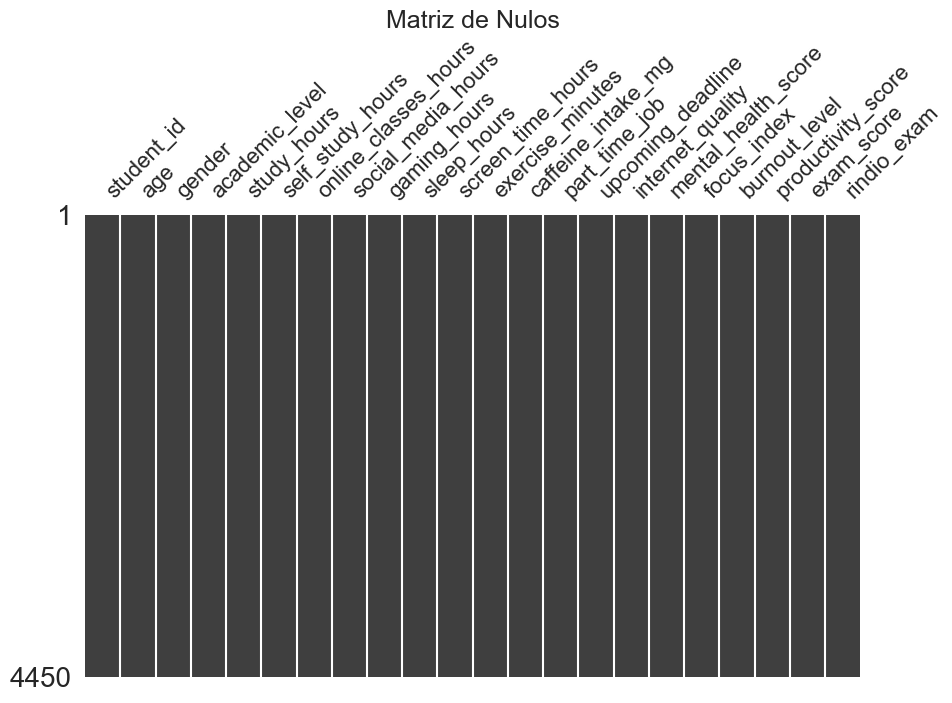

In [81]:
# Cantidad exacta de nulos por variable
print(df.isnull().sum())

# Visualización de matriz de datos faltantes
plt.figure(figsize=(10, 6))
msn.matrix(df, figsize=(10, 6), sparkline=False)
plt.title('Matriz de Nulos', fontsize=18)
plt.show()

## 2. Modelo de Probabilidad Lineal - MCO

### Selección de Variables Continuas y Categoricas(Enfoque Forward Selection)

Para seleccionar las variables para que el modelo resulte robusto y parsimonioso, sin tener problemas de multicolinealidad, se ha utilizado el metodo forward selection, esto es comenzar con un modelo nulo y luego ir agregando variables (apoyandome con el heatmap) que demuestren tener un efecto sobre nuestra variable dependiente "rindio_exam"
Las variables seleccionadas fueron productivity_score , sleep_hours y screen_time_hours

Luego para seleccionar las variables categoricas se han realizado graficos de barras junto a la probabilidad, esto para ver que categorias presentan variabilidad, y por lo tanto, las que tienen poder predictivo

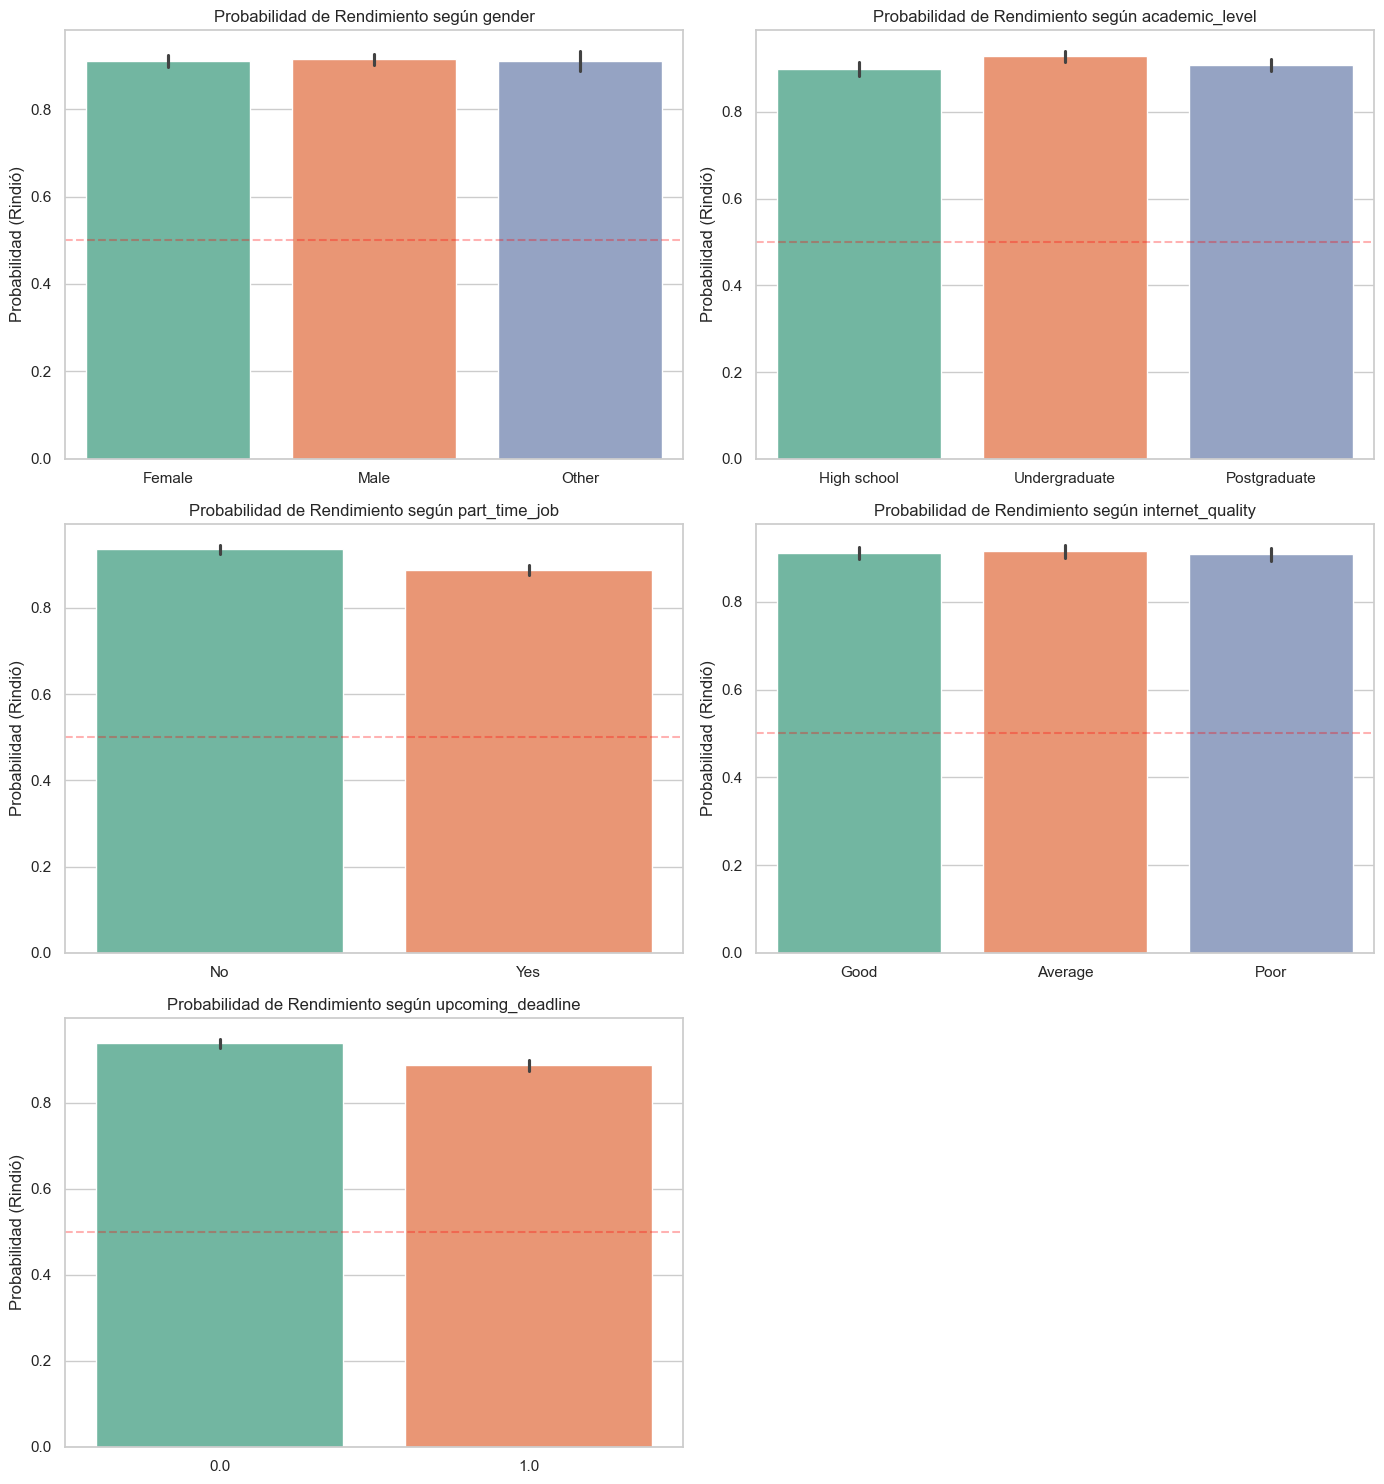

In [82]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

variables_categoricas = [
    'gender', 'academic_level', 'part_time_job', 
    'internet_quality', 'upcoming_deadline'
]

n_cols_cat = 2
n_rows_cat = math.ceil(len(variables_categoricas) / n_cols_cat)

fig, axes = plt.subplots(n_rows_cat, n_cols_cat, figsize=(14, 5 * n_rows_cat))
axes = axes.flatten()

for i, col in enumerate(variables_categoricas):
    if col in df.columns:
        sns.barplot(data=df, x=col, y='rindio_exam', ax=axes[i], palette='Set2')
        axes[i].set_title(f'Probabilidad de Rendimiento según {col}', fontsize=12)
        axes[i].set_ylabel('Probabilidad (Rindió)')
        axes[i].set_xlabel('')
        axes[i].axhline(0.5, color='red', linestyle='--', alpha=0.3)

for j in range(len(variables_categoricas), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

Análisis:
De los gráficos se observa que variables como "gender" o "internet_quality" tienen distribuciones probabilísticas planas, por lo que no aportan ganancia al modelo. En cambio, "upcoming_deadline", "academic_level" y "part_time_job" muestran claras diferencias probabilísticas por categoria. Estas últimas entran en nuestra selección.

In [83]:
import scipy.stats as stats
import pandas as pd

print("=== PRUEBAS CHI CUADRADO (INDEPENDENCIA) ===")
categoricas = ['gender', 'academic_level', 'part_time_job', 'internet_quality', 'upcoming_deadline']

for cat in categoricas:
    if cat in df.columns:
        contingency = pd.crosstab(df[cat], df['rindio_exam'])
        chi2, p, dof, ex = stats.chi2_contingency(contingency)
        # Formateo de p-value para rápida lectura
        significancia = "RECHAZADO (No sirve)" if p > 0.05 else "ACEPTADO (Significativo)"
        print(f"{cat.ljust(20)}: p-value = {p:.5f} -> {significancia}")

=== PRUEBAS CHI CUADRADO (INDEPENDENCIA) ===
gender              : p-value = 0.93344 -> RECHAZADO (No sirve)
academic_level      : p-value = 0.01457 -> ACEPTADO (Significativo)
part_time_job       : p-value = 0.00000 -> ACEPTADO (Significativo)
internet_quality    : p-value = 0.79684 -> RECHAZADO (No sirve)
upcoming_deadline   : p-value = 0.00000 -> ACEPTADO (Significativo)


Respaldo Estadístico ($\chi^2$):
El test de independencia comprueba matemáticamente lo que vimos en los gráficos. Variables como "gender" e "internet_quality" tienen un p-value alto, confirmando que carecen de impacto predictivo sobre la decisión de rendir el examen. Por el contrario, "academic_level", "part_time_job" y "upcoming_deadline" superan la prueba al tener p-value < 0.05, confirmando la seleccion intuitiva a partir de los graficos.



### Estimación del Modelo Lineal de Probabilidad (OLS/MCO)
Con nuestra selección realizada pasamos a estimar. Debido a que la variable objetivo es binaria, un modelo MCO clásico sufre de heterocedasticidad. Para corregir esto, se usara la matriz de varianzas robusta (HC3).

In [112]:
import statsmodels.formula.api as smf

formula_final = 'rindio_exam ~ C(academic_level) + C(part_time_job) + C(upcoming_deadline) + productivity_score + sleep_hours + screen_time_hours'

modelo_mco = smf.ols(formula=formula_final, data=df).fit(cov_type='HC3')
print("============= RESULTADOS MODELO PROBABILIDAD LINEAL (MCO) =============\n")
print(modelo_mco.summary())

============= RESULTADOS MODELO PROBABILIDAD LINEAL (MCO) =============

                            OLS Regression Results                            
Dep. Variable:            rindio_exam   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.238
Method:                 Least Squares   F-statistic:                     91.53
Date:                Sat, 18 Apr 2026   Prob (F-statistic):          4.35e-125
Time:                        04:14:52   Log-Likelihood:                -96.321
No. Observations:                4450   AIC:                             208.6
Df Residuals:                    4442   BIC:                             259.8
Df Model:                           7                                         
Covariance Type:                  HC3                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------

### Interpretación Lineal de la Probabilidad
El modelo con un R cuadrado de 0.238

En un Modelo de Probabilidad Lineal (MCO), los coeficientes se leen directamente como efectos marginales constantes. Ceteris paribus, la estimación indica que:

**Productividad**: Un aumento de un punto de prodcutividad incrementa en 0.76 puntos porcentuales a la probabilidad de rendir el examen.

**Trabajo** (part_time_job): Estudiantes que poseen un trabajo tienen una disminucion probabilística de 2.16 puntos porcentuales de rendir el examen frente a los que no trabajan.

**Entrega proxima** (upcoming_deadline): Estudiantes que deben realizar una entrega pronto muestran una disminucion de 2.06 puntos porcentuales en la probabilidad de rendir el examen frente a los que no tienen entregas proximas. 

**Undergraduate**: Estar en la categoria "Undergraduate" incrementa en 2.92 puntos porcentuales la probabilidad de rendir el examen frente a la categoria base (High School)

**Horas de sueño** (slepp_hours): Por cada hora de sueño del estudiante, estos muestran un aumento de 1.65 puntos porcentuales la probabilidad de rendir el examen.

**Horas frente a pantallas** (screen_time_hours): Por cada hora adicional que pasa el estudiante frente a una pantalla disminuye la probabilidad de rendir el examen en 0.6 puntos porcentuales.

El coeficiente de "Postgraduate" no se ha analizado por carecer nivel significativo.



## 3. Modelo Probit
(Mismas variables que MCO)

In [85]:
import statsmodels.api as sm

modelo_probit = smf.probit(formula=formula_final, data=df).fit(disp=0)
margeff_probit = modelo_probit.get_margeff(at='overall')

print("============= COEFICIENTES BRUTOS PROBIT =============\n")
print(modelo_probit.summary())
print("\n============= EFECTOS MARGINALES PROMEDIO (PROBIT) =============\n")
print(margeff_probit.summary())

============= COEFICIENTES BRUTOS PROBIT =============

                          Probit Regression Results                           
Dep. Variable:            rindio_exam   No. Observations:                 4450
Model:                         Probit   Df Residuals:                     4442
Method:                           MLE   Df Model:                            7
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                  0.5555
Time:                        03:04:54   Log-Likelihood:                -589.63
converged:                       True   LL-Null:                       -1326.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -2.0708      0.301     -6.891      0.000      -2.660      -1.482
C(a

**Interpretación de Efectos Marginales**


A diferencia del modelo MCO, los coeficientes entregados por el modelo probit se miden en z-scores, por esto se ha calculado sus efectos marginales para una mejor interpretacion, Ceteris paribus.

Los efectos marginales del modelo probit resultaron ser practicamente iguales a los del modelo MCO, variando solo por milesimas y teniendo los mismos niveles de significancia.

Las variables de productividad y horas de sueño incrementan la probabilidad de rendir el examen, mientras que las horas frente a una pantalla, tener entregas pronto y trabajar tienen un efecto negativo en la probabilidad de rendir el examen, exactamente como en el modelo MCO.




## 4.LOGIT 
El modelo Logit modeliza el problema a través de una función logística. De forma análoga se calcularan sus Efectos Marginales Promedio ($dy/dx$).

In [113]:
modelo_logit = smf.logit(formula=formula_final, data=df).fit(disp=0)
margeff_logit = modelo_logit.get_margeff(at='overall')

print("============= COEFICIENTES BRUTOS LOGIT =============\n")
print(modelo_logit.summary())
print("\n============= EFECTOS MARGINALES PROMEDIO (LOGIT) =============\n")
print(margeff_logit.summary())

============= COEFICIENTES BRUTOS LOGIT =============

                           Logit Regression Results                           
Dep. Variable:            rindio_exam   No. Observations:                 4450
Model:                          Logit   Df Residuals:                     4442
Method:                           MLE   Df Model:                            7
Date:                Sat, 18 Apr 2026   Pseudo R-squ.:                  0.5576
Time:                        04:16:28   Log-Likelihood:                -586.92
converged:                       True   LL-Null:                       -1326.5
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -4.0406      0.563     -7.171      0.000      -5.145      -2.936
C(ac

**Interpretación de Efectos Marginales (Logit):**

Analizando los efectos marginales del modelo logit podemos ver que estos convergen a los del modelo probit, tanto en coeficientes como en significancia, lo que avala la seleccion de las variables independiente del supuesto distribucional asumido.

Se opto por no calcular e interpretar los odds ratio del modelo logit para interpretar los 3 modelos mediante sus efectos marginales y poder compararlos correctamente

## 5. Análisis Comparativo 

Al comparar los resultados del modelo MCO, Probit y Logit, el resultado es claro, hubo una fuerte tendencia. Las seis variables predictoras mantuvieron su direccion y significancia en todos los modelos, validando que habitos como el sueño y la productividad afectan positivamente la probabilidad de que un estudiante rinda el examen, mientras que las horas frente a una pantalla, trabajar o la carga de tener una entrega pronto afectan negativamente a la probabilidad de rendir el examen.

Para ver las diferencias entre los modelos no debemos analizar directamente sus coeficientes, si no que analizar sus efectos marginales, ya que el MCO usa una recta para modelar, el modelo probit usa la distribucion normal, mientras que el logit usa la distribucion logistica, haciendo que la directa interpretacion no sea correcta. Al aislar los efectos marginales promedios (dy/dx) no hubo grandes diferencias ya que los coeficientes y sus niveles de significancias se diferencian a nivel de milesimas.

Para responder la pregunta de investigacion, el modelo a usar deben ser si o si el probit o logit ya que estos son modelos correctos para variables binarias y que entregan resultados logicos entre 0% y 100%, descartando al MCO por ser un modelo que supone relacion lineal y puede arrojar resultados fuera de rango. 

Para decir que una variable es robusta debe cumplir que esta mantenga su signo y significancia independiente del modelo que usemos, bajo este criterio todas las variables que inclui en el modelo resultaron ser robustas.
Variables de buen hábito, como tener alta productividad (productivity_score) y dormir lo suficiente (sleep_hours), se mantuvieron aumentando la probabilidad de rendir el examen.
En paralelo, las variables de estrés situacional, como estar empleado a medio tiempo (part_time_job) o tener fechas de entrega (upcoming_deadline), mantuvieron su impacto negativo disminuyendo la probabilidad en los tres análisis.



## 6.Regresión Poisson 

Habiendo ya analizado el problema de rendicion del examen (variable discreta binaria), pasamos al modelado del rendimiento: la nota del examen ("exam_score"). Resulta fundamental filtrar únicamente a la población que rindió la prueba, para evitar sesgar el comportamiento de estudio con estudiantes que obtuvieron la nota base por inasistencia.

### Justificación Teórica del Modelo Poisson vs OLS Continúo
Aunque intuitivamente uno abordaría evaluaciones a través de un simple MCO debido a la aparente naturaleza continua del puntaje, el abordaje vía OLS puede estar matemáticamente sub-calibrado en fronteras restrictivas.

El sistema Rectilíneo OLS asume invariabilidad condicional (Homocedasticidad) y podría erróneamente predecir puntajes menores a cero. Para resolver este quiebre geométrico, empleamos el Estimador Cuasi-Máxima Verosimilitud Poisson. Esta distribución dobla su cola predicha evitando invadir jamás dominios negativos.

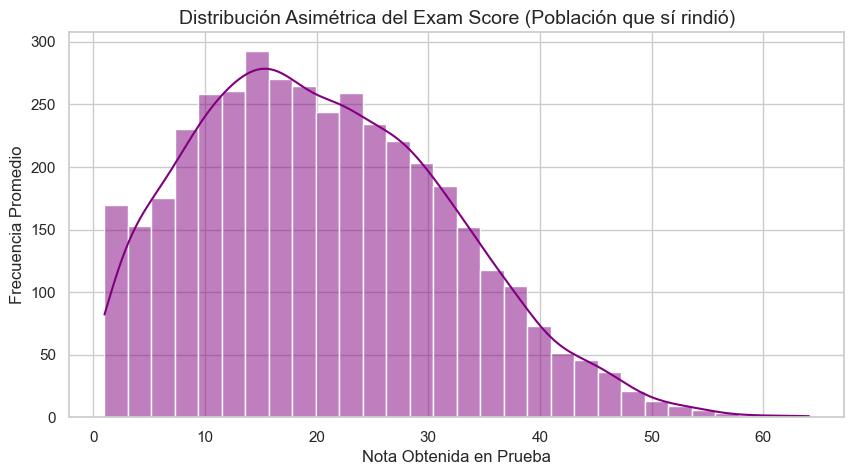

In [114]:
# Filtramos nuestra BD solo para rendidores (1=Asistió)
df_exam = df[df['rindio_exam'] == 1].copy()

plt.figure(figsize=(10, 5))
sns.histplot(df_exam['exam_score'], bins=30, kde=True, color='purple')
plt.title('Distribución Asimétrica del Exam Score (Población que sí rindió)', fontsize=14)
plt.xlabel('Nota Obtenida en Prueba')
plt.ylabel('Frecuencia Promedio')
plt.show()

Como podemos observar en el gráfico anterior, la distribución de las notas de los estudiantes no tiene la forma de una campana perfecta y simétrica (Campana de Gauss).

Esto es revelador: el modelo lineal clásico (MCO) exige estrictamente que los datos se comporten como esa "campana perfecta" para funcionar de forma correcta. Sin embargo, en la vida real las notas no se distribuyen así, vemos que se acumulan e inclinan de forma irregular con una tendencia a la izquierda (notas bajas).

Para poder predecir sobre este tipo de datos desiguales e imperfectos sin cometer errores estadísticos, utilizamos el modelo de regresión de Poisson, un algoritmo diseñado matemáticamente a la medida para trabajar con variables que se agrupan de esta manera.





In [115]:
formula_nota = 'exam_score ~ C(academic_level) + C(part_time_job) + C(upcoming_deadline) + productivity_score + sleep_hours + screen_time_hours'

modelo_poisson = smf.poisson(formula=formula_nota, data=df_exam).fit(method='bfgs')

print("============= RESULTADO ESTRUCTURAL REGRESIÓN POISSON =============\n")
print(modelo_poisson.summary())

# Computamos el impacto porcentual bruto (semi-elasticidad descompuesta)
# La ecuación es: [ Exponencial del coeficiente Beta (log) - 1 ] * 100
print("\n=== IMPACTO PORCENTUAL SOBRE EL RENDIMIENTO CALIFICADO (% Promedio Esperado) ===")
print((np.exp(modelo_poisson.params) - 1) * 100)

Optimization terminated successfully.
         Current function value: 3.307686
         Iterations: 16
         Function evaluations: 24
         Gradient evaluations: 24
============= RESULTADO ESTRUCTURAL REGRESIÓN POISSON =============

                          Poisson Regression Results                          
Dep. Variable:             exam_score   No. Observations:                 4058
Model:                        Poisson   Df Residuals:                     4050
Method:                           MLE   Df Model:                            7
Date:                Sat, 18 Apr 2026   Pseudo R-squ.:                  0.4124
Time:                        05:52:52   Log-Likelihood:                -13423.
converged:                       True   LL-Null:                       -22843.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------

### Interpretación 

A diferencia de los modelos que predecian si el alumno rendia el examen o no, al predecir la nota que obtendra el alumno la variables academic_level pierde toda su significancia ya que sus p-values son mayores a nuestro umbral 0-05. La nota pasa a estar dependiente solo de los habitos.

Al aislar las verdaderas determinantes bajo, ceteris paribus:
1. **Sleep Hours (+5.5 %):** Ganar una hora de sueño adicional aumenta notoriamente la nota del alumno.
2. **Productivity Score (+2.8 %):** Sumar una unidad en el medidor de productividad aumenta las notas de los alumnos.
3. **Toxicidad Digital - Screen Time (-1.29 %):** Aumentar una hora frente a una pantalla irrelevante disminuye un valioso potencial de nota.
4. **Factor de Compromisos:** Aca podemos ver como la variable de trabajar (part_time_job) y tener una entrega (upcoming_deadline) disminuyen en 6 y 11 % respectivamente, afectando gravemente las notas de los alumnos, exigiendo que estos para obtener buenas notas tengan un alto nivel de productividad, buenas horas de sueño y nulas horas frente a una pantalla.

## 7. Diagnóstico Sobre-dispersión y Función de Alpha 

La debilidad principal del modelo Poisson es que asume de manera estricta que nuestras notas tienen "Equidispersión". Es decir, asume que la media de las notas es matemáticamente idéntica a su varianza.

El problema es que, en la vida real, las calificaciones de los estudiantes fluctúan de manera muchísimo más de lo que dicta este supuesto equilibrado (fenómeno conocido como Sobredispersión). Si usamos Poisson cuando existe este exceso de varianza empírica, el modelo cometerá un gran error de auto-engaño, subestimará los errores estándar de la tabla. Al tener errores, arrojará p-values irrealmente bajos, haciéndonos concluir erróneamente que ciertas variables son significativas cuando no lo son (generando falsos positivos).

Para proteger nuestro análisis y confirmar estadísticamente si sufrimos de esta sobredispersión, calculamos la prueba auxiliar que revelará a nuestro coeficiente alpha, el cual medirá si efectivamente hay un exceso de varianza no capturado

In [118]:
# 1. Rescatamos el vector predictivo de Poisson (Tasa Promedio Asumida Lambda)
df_exam["lambda_poisson"] = modelo_poisson.predict()

# 2. Computamos el parámetro condicional de penalidad (Auxiliar)
df_exam["aux"] = ((df_exam["exam_score"] - df_exam["lambda_poisson"])**2 - df_exam["lambda_poisson"]) / df_exam["lambda_poisson"]

# 3. Modelamos deviancia vs proyecciones con OLS puro sin origen cartesiano forzado ("- 1")
modelo_overdispersion = smf.ols("aux ~ lambda_poisson - 1", data=df_exam).fit()
print("============= DIAGNÓSTICO ESTRUCTURAL DE SOBRE-DISPERSIÓN =============\n")
print(modelo_overdispersion.summary())

# 4. Captura Paramétrica del Coeficiente Multiplicador (Alpha)
alpha_estimado = modelo_overdispersion.params["lambda_poisson"]
print(f"\n VALOR ALFA ÓPTIMO CONFIRMADO: {alpha_estimado:.4f}")

============= DIAGNÓSTICO ESTRUCTURAL DE SOBRE-DISPERSIÓN =============

                                 OLS Regression Results                                
Dep. Variable:                    aux   R-squared (uncentered):                   0.052
Model:                            OLS   Adj. R-squared (uncentered):              0.052
Method:                 Least Squares   F-statistic:                              222.6
Date:                Mon, 20 Apr 2026   Prob (F-statistic):                    4.69e-49
Time:                        06:39:16   Log-Likelihood:                         -9756.8
No. Observations:                4058   AIC:                                  1.952e+04
Df Residuals:                    4057   BIC:                                  1.952e+04
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                     coef    std err          t

### Conclusión

Los resultados de la prueba nos indican que alpha es 0.0272 y significativo, mayor a cero, por lo tanto se rechaza la hipotesis nula de equidispersion del modelo poisson. El modelo sufre sobredispersion y no es el adecuado para esto, se debe proceder con el modelo binomial-negativa




## 8.Binomial Negativa

Al confirmar estadísticamente que nuestras notas sufren de un exceso de sobredispersión, tomamos el valor del parámetro de penalidad que acabamos de descubrir (Alpha: 0.0272) y lo utilizamos para calcular el modelo que solucionará el problema: la Regresión Binomial Negativa.



In [117]:
# 1. Declaramos estructuralmente la magnitud del factor de sobredispersión recolectado
alpha_parametrizado = 0.0272

# 2. Ejecutamos GLM (Generalized Linear Model) de statsmodels
# Forzando a su Familia Distribucional Interna a acatar ciegamente y anclar nuestro Alfa
modelo_bn = smf.glm(formula=formula_nota, 
                    data=df_exam, 
                    family=sm.families.NegativeBinomial(alpha=alpha_parametrizado)).fit()

print("============= RESULTADOS OFICIALES ESTRUCTURALES BINOMIAL NEGATIVA =============\n")
print(modelo_bn.summary())

# 3. Retorno de Semi-Elasticidades Exponenciales Legibles
print("\n=== EFECTO PORCENTUAL VERDADERO EN LA NOTA ESPERADA (Exp-1) ===")
print((np.exp(modelo_bn.params) - 1) * 100)

============= RESULTADOS OFICIALES ESTRUCTURALES BINOMIAL NEGATIVA =============

                 Generalized Linear Model Regression Results                  
Dep. Variable:             exam_score   No. Observations:                 4058
Model:                            GLM   Df Residuals:                     4050
Model Family:        NegativeBinomial   Df Model:                            7
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -13084.
Date:                Sat, 18 Apr 2026   Deviance:                       5491.3
Time:                        22:08:43   Pearson chi2:                 5.03e+03
No. Iterations:                     6   Pseudo R-squ. (CS):             0.9518
Covariance Type:            nonrobust                                         
                                         coef    std err          z      P>|z|      [0.025      0.975]
-------------------------

### Interpretación 
Al observar los resultados, el impacto porcentual de cada variable sobre la nota se mantiene prácticamente idéntico al que ya describimos en el modelo de Poisson. Hábitos como el buen dormir o la carga laboral siguen bonificando o hundiendo la nota final en las mismas proporciones.

La verdadera importancia de correr este segundo modelo se encuentra en la columna de los Errores Estándar. Al sumar nuestra penalidad alpha a la fórmula, obligamos a la "Binomial Negativa" a ser mucho más estricto que Poisson. Esto hizo que todos los márgenes de error crecieran a límites reales, haciendo que sea mucho más difícil que una variable parezca "estadísticamente significativa".

Sin embargo, a pesar de someter nuestras variables a este duro filtro corrector, todas ellas mantuvieron su nivel de significancia. Este hecho nos permite asegurar de forma honesta y definitiva que variables como el nivel de productividad, sueño, o poseer obligaciones paralelas, influyen determinantemente en la nota del alumno, y desmiente que estos hallazgos hayan sido una casualidad probabilística.


## 9. Discusión Final: Poisson y Binomial Negativa 

La conclusión general es que tanto el modelo de Poisson como la Binomial Negativa respaldan exactamente las mismas variables de rendimiento para los estudiantes. Descansar y ser productivos eleva las notas, mientras que el ocio tecnológico y las altas obligaciones externas (laborales o académicas) la reducen gravemente. Las variables demostraron ser robustas.

Al ver los resultados, los coeficientes (porcentajes de impacto) de Poisson y Binomial Negativa son casi los mismos. La diferencia aparece exclusivamente en la columna de sus "Errores Estándar". Esta disparidad ocurre por una falla matemática: Poisson teóricamente asume que la nota promedio de los alumnos no puede fluctuar ni tener una varianza más grande que su propia media. Como en la vida real las notas fluctúan muchísimo más que la media (sobredispersión probada en el paso 7), Poisson subestimó los errores. La Binomial Negativa solucionó esta diferencia metiendo nuestro alpha a su fórmula, haciendo crecer los errores a su verdadero tamaño real.

Para predecir el puntaje definitivo, el ganador absoluto es la Binomial Negativa. Por un lado, desecha los problemas lógicos en los que hubiese caído un modelo MCO. Por otro lado, rescata la naturaleza de conteo positivo que tiene Poisson, pero solucionando su grave problema frente a las grandes varianzas.

Todas las métricas de comportamiento estudiantil resultaron robustas. Específicamente, sleep_hours, productivity_score, screen_time_hours, junto a part_time_job y upcoming_deadline. Incluso bajo la Binomial Negativa, ni una sola de ellas perdio su nivel de significancia. Como gran dato revelador, confirmamos que el atributo categórico de estatus universitario (academic_level) demostró no ser robusto. Si bien determinó fuertemente si el estudiante asistiría inicialmente o no al examen (Modelos 1, 2 y 3), su fuerza predictiva desapareció por completo cuando el objetivo mutó a predecir la calificación de los que sí presentaban.




